In [2]:
install.packages("factoextra")

also installing the dependencies ‘crosstalk’, ‘DT’, ‘ellipse’, ‘flashClust’, ‘multcompView’, ‘dendextend’, ‘FactoMineR’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
library(tidyverse)
library(factoextra)  # For PCA visualization and k-means
library(repr)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



In [4]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
library(showtext)
font_add_google("Lato", "lato")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [25]:
# Cut distributions at the point where there's minimal variability among subjects
cut_degree_distributions <- function(node_df, PID, node_degree, threshold = .05) {
  # Find the highest degree where at least threshold_percent% of subjects have nodes
  
  # Calculate total number of subjects
  total_subjects <- length(unique(node_df %>% pull(PID)))
  
  # For each degree value, count how many distinct subjects have nodes with that degree
  degree_counts <- node_df %>%
    filter({{ node_degree }} > 0) %>%
    group_by({{ node_degree }}) %>%
    summarize(subject_count = n_distinct({{ PID }}),
              subject_ratio = n_distinct({{ PID }}) / total_subjects,
              .groups = "drop")
  
  # Find the maximum degree that meets the threshold
  max_relevant_degree <- degree_counts %>%
    filter(subject_ratio >= threshold) %>%
    pull({{ node_degree }}) %>%
    max(na.rm = TRUE)

  print(max_relevant_degree)
  # Filter the dataframe to include only degrees up to the max relevant degree
  node_df %>%
    filter({{ node_degree }} <= max_relevant_degree)
}

In [33]:
# Perform PCA and find knee point in eigenspectrum
perform_pca_with_knee <- function(node_df, PID, group, node_id, node_degree, threshold = 0.9) {
  # First, reshape data to wide format for PCA
  # Each row is a subject (PID), columns are node degrees
  pca_ready_data <- node_df %>%
    pivot_wider(
      id_cols = c({{ PID }}, {{ group }}),
      names_from = {{ node_id }},
      values_from = {{ node_degree }},
      values_fill = 0  # Fill missing combinations with 0
    )
  
  # Extract subject identifiers before PCA
  subject_info <- pca_ready_data %>% select({{ PID }}, {{ group }})
  
  # Run PCA on the node degree data
  pca_data <- pca_ready_data %>% select(-{{ PID }}, -{{ group }})
  pca_result <- prcomp(pca_data, scale. = TRUE)
  
  # Calculate variance explained
  var_explained <- pca_result$sdev^2 / sum(pca_result$sdev^2)
  cum_var <- cumsum(var_explained)
  
  # Find knee point (components that explain threshold% of variance)
  knee_point <- which(cum_var >= threshold)[1]
  
  # Return PCA results with subject info
  list(
    pca_obj = pca_result,
    knee_point = knee_point,
    pca_data = as_tibble(pca_result$x) %>% 
      bind_cols(subject_info),
    var_explained = var_explained
  )
}

In [36]:
# Plot eigenspectrum with knee point
plot_eigenspectrum <- function(pca_result) {
  var_explained <- pca_result$var_explained
  knee_point <- pca_result$knee_point
  
  tibble(
    component = 1:length(var_explained),
    variance = var_explained,
    cumulative = cumsum(var_explained)
  ) %>%
    pivot_longer(cols = c(variance, cumulative), 
                 names_to = "type", 
                 values_to = "value") %>%
    ggplot(aes(x = component, y = value, color = type)) +
    geom_line() +
    geom_point() +
    geom_vline(xintercept = knee_point, linetype = "dashed", color = "red") +
    annotate("text", x = knee_point + 1, y = max(var_explained), 
             label = paste("Knee =", knee_point), hjust = 0) +
    scale_x_continuous(breaks = 1:length(var_explained)) +
    labs(title = "PCA Eigenspectrum with Knee Point",
         x = "Principal Component",
         y = "Proportion of Variance") +
    theme_minimal()
}

In [40]:
# Visualize first 2 PCs with group coloring
plot_first_two_pcs <- function(pca_result) {
  # Create scatterplot of first two principal components
  pca_result$pca_data %>%
    ggplot(aes(x = PC1, y = PC2, color = group)) +
    geom_point(alpha = 0.7, size = 3) +
    stat_ellipse(level = 0.95, linetype = 2) +
    labs(
      title = "Distribution of First Two Principal Components",
      x = paste0("PC1 (", round(pca_result$var_explained[1] * 100, 1), "% variance)"),
      y = paste0("PC2 (", round(pca_result$var_explained[2] * 100, 1), "% variance)")
    ) +
    theme_minimal() +
    theme(
      legend.position = "bottom",
      panel.grid.minor = element_blank()
    ) +
    scale_color_brewer(palette = "Set1")
}

In [42]:
# Whiten data and perform k-means clustering
cluster_data <- function(pca_result, k = 2, pcs_to_use = NULL) {
  # If pcs_to_use not specified, use up to the knee point
  if (is.null(pcs_to_use)) {
    pcs_to_use <- 1:pca_result$knee_point
  }
  
  # Extract PCs to use for clustering
  pc_columns <- paste0("PC", pcs_to_use)
  
  # Whiten the data (scale to unit variance)
  whitened_data <- pca_result$pca_data %>%
    select(all_of(pc_columns)) %>%
    scale()
  
  # Perform k-means clustering
  set.seed(42)  # For reproducibility
  km_result <- kmeans(whitened_data, centers = k, nstart = 25)
  
  # Add cluster assignments to original PCA data
  clustered_data <- pca_result$pca_data %>%
    mutate(cluster = as.factor(km_result$cluster))
  
  # Return all results
  list(
    km_obj = km_result,
    clustered_data = clustered_data,
    whitened_data = whitened_data
  )
}

In [47]:
# Visualize clusters in PC space
plot_clusters <- function(cluster_result) {
  cluster_result$clustered_data %>%
    ggplot(aes(x = PC1, y = PC2, color = cluster)) +
    geom_point(alpha = 0.7) +
    stat_ellipse(aes(group = cluster), level = 0.95) +
    labs(title = paste("K-means Clustering (k =", 
                       length(unique(cluster_result$clustered_data$cluster)), ")"),
         x = "PC1", y = "PC2") +
    theme_minimal() +
    scale_color_brewer(palette = "Set1")
}


In [51]:
# Analyze distribution of groups between clusters
analyze_cluster_groups <- function(cluster_result) {
  # Calculate counts and proportions of each group within clusters
  group_distribution <- cluster_result$clustered_data %>%
    count(cluster, group) %>%
    group_by(cluster) %>%
    mutate(
      total = sum(n),
      proportion = n / total
    ) %>%
    ungroup()
  
  # Create visualization of group distribution by cluster
  plot <- group_distribution %>%
    ggplot(aes(x = cluster, y = proportion, fill = group)) +
    geom_col() +
    geom_text(
      aes(label = paste0(round(proportion * 100, 1), "%")),
      position = position_stack(vjust = 0.5),
      color = "white",
      fontface = "bold"
    ) +
    labs(
      title = "Distribution of Groups Across Clusters",
      x = "Cluster",
      y = "Proportion",
      fill = "Group"
    ) +
    scale_y_continuous(labels = scales::percent) +
    theme_minimal() +
    scale_fill_brewer(palette = "Set1")
  
  # Return both the data and the plot
  list(
    distribution_data = group_distribution,
    plot = plot
  )
}


In [60]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "control", "central"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


[1] 20


Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“semi-transparency is not supported on this device: reported only once per page”


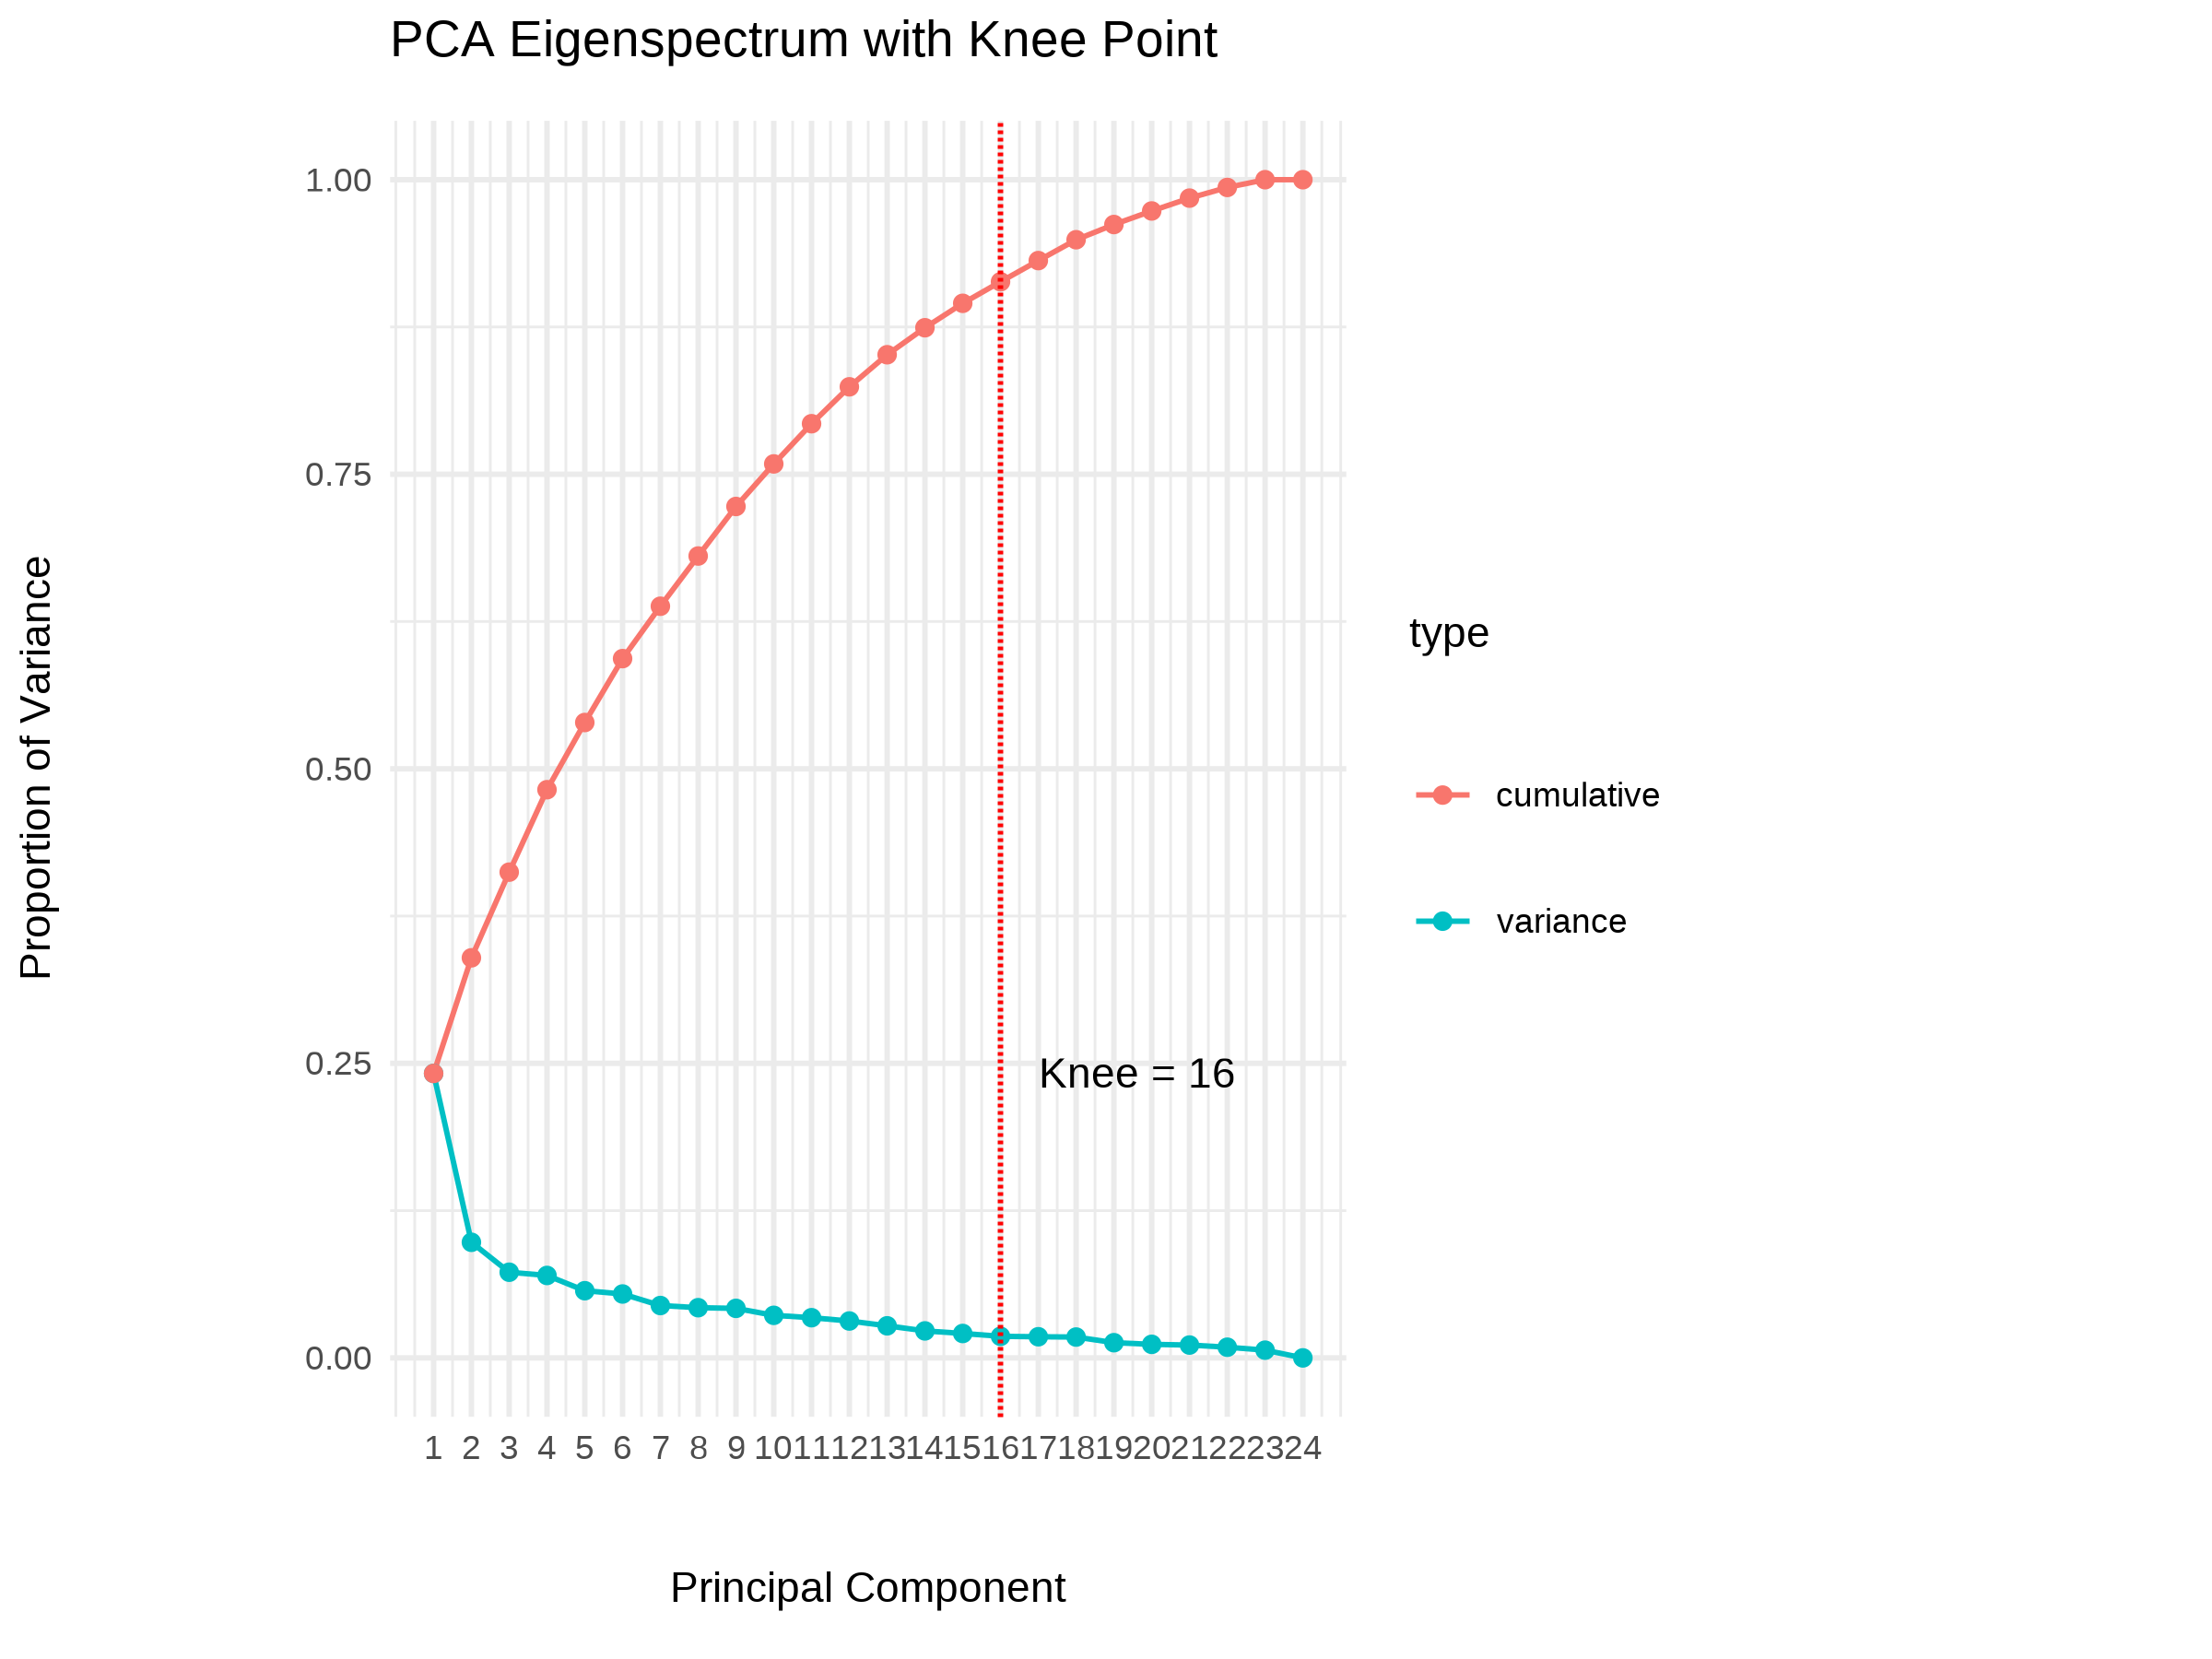

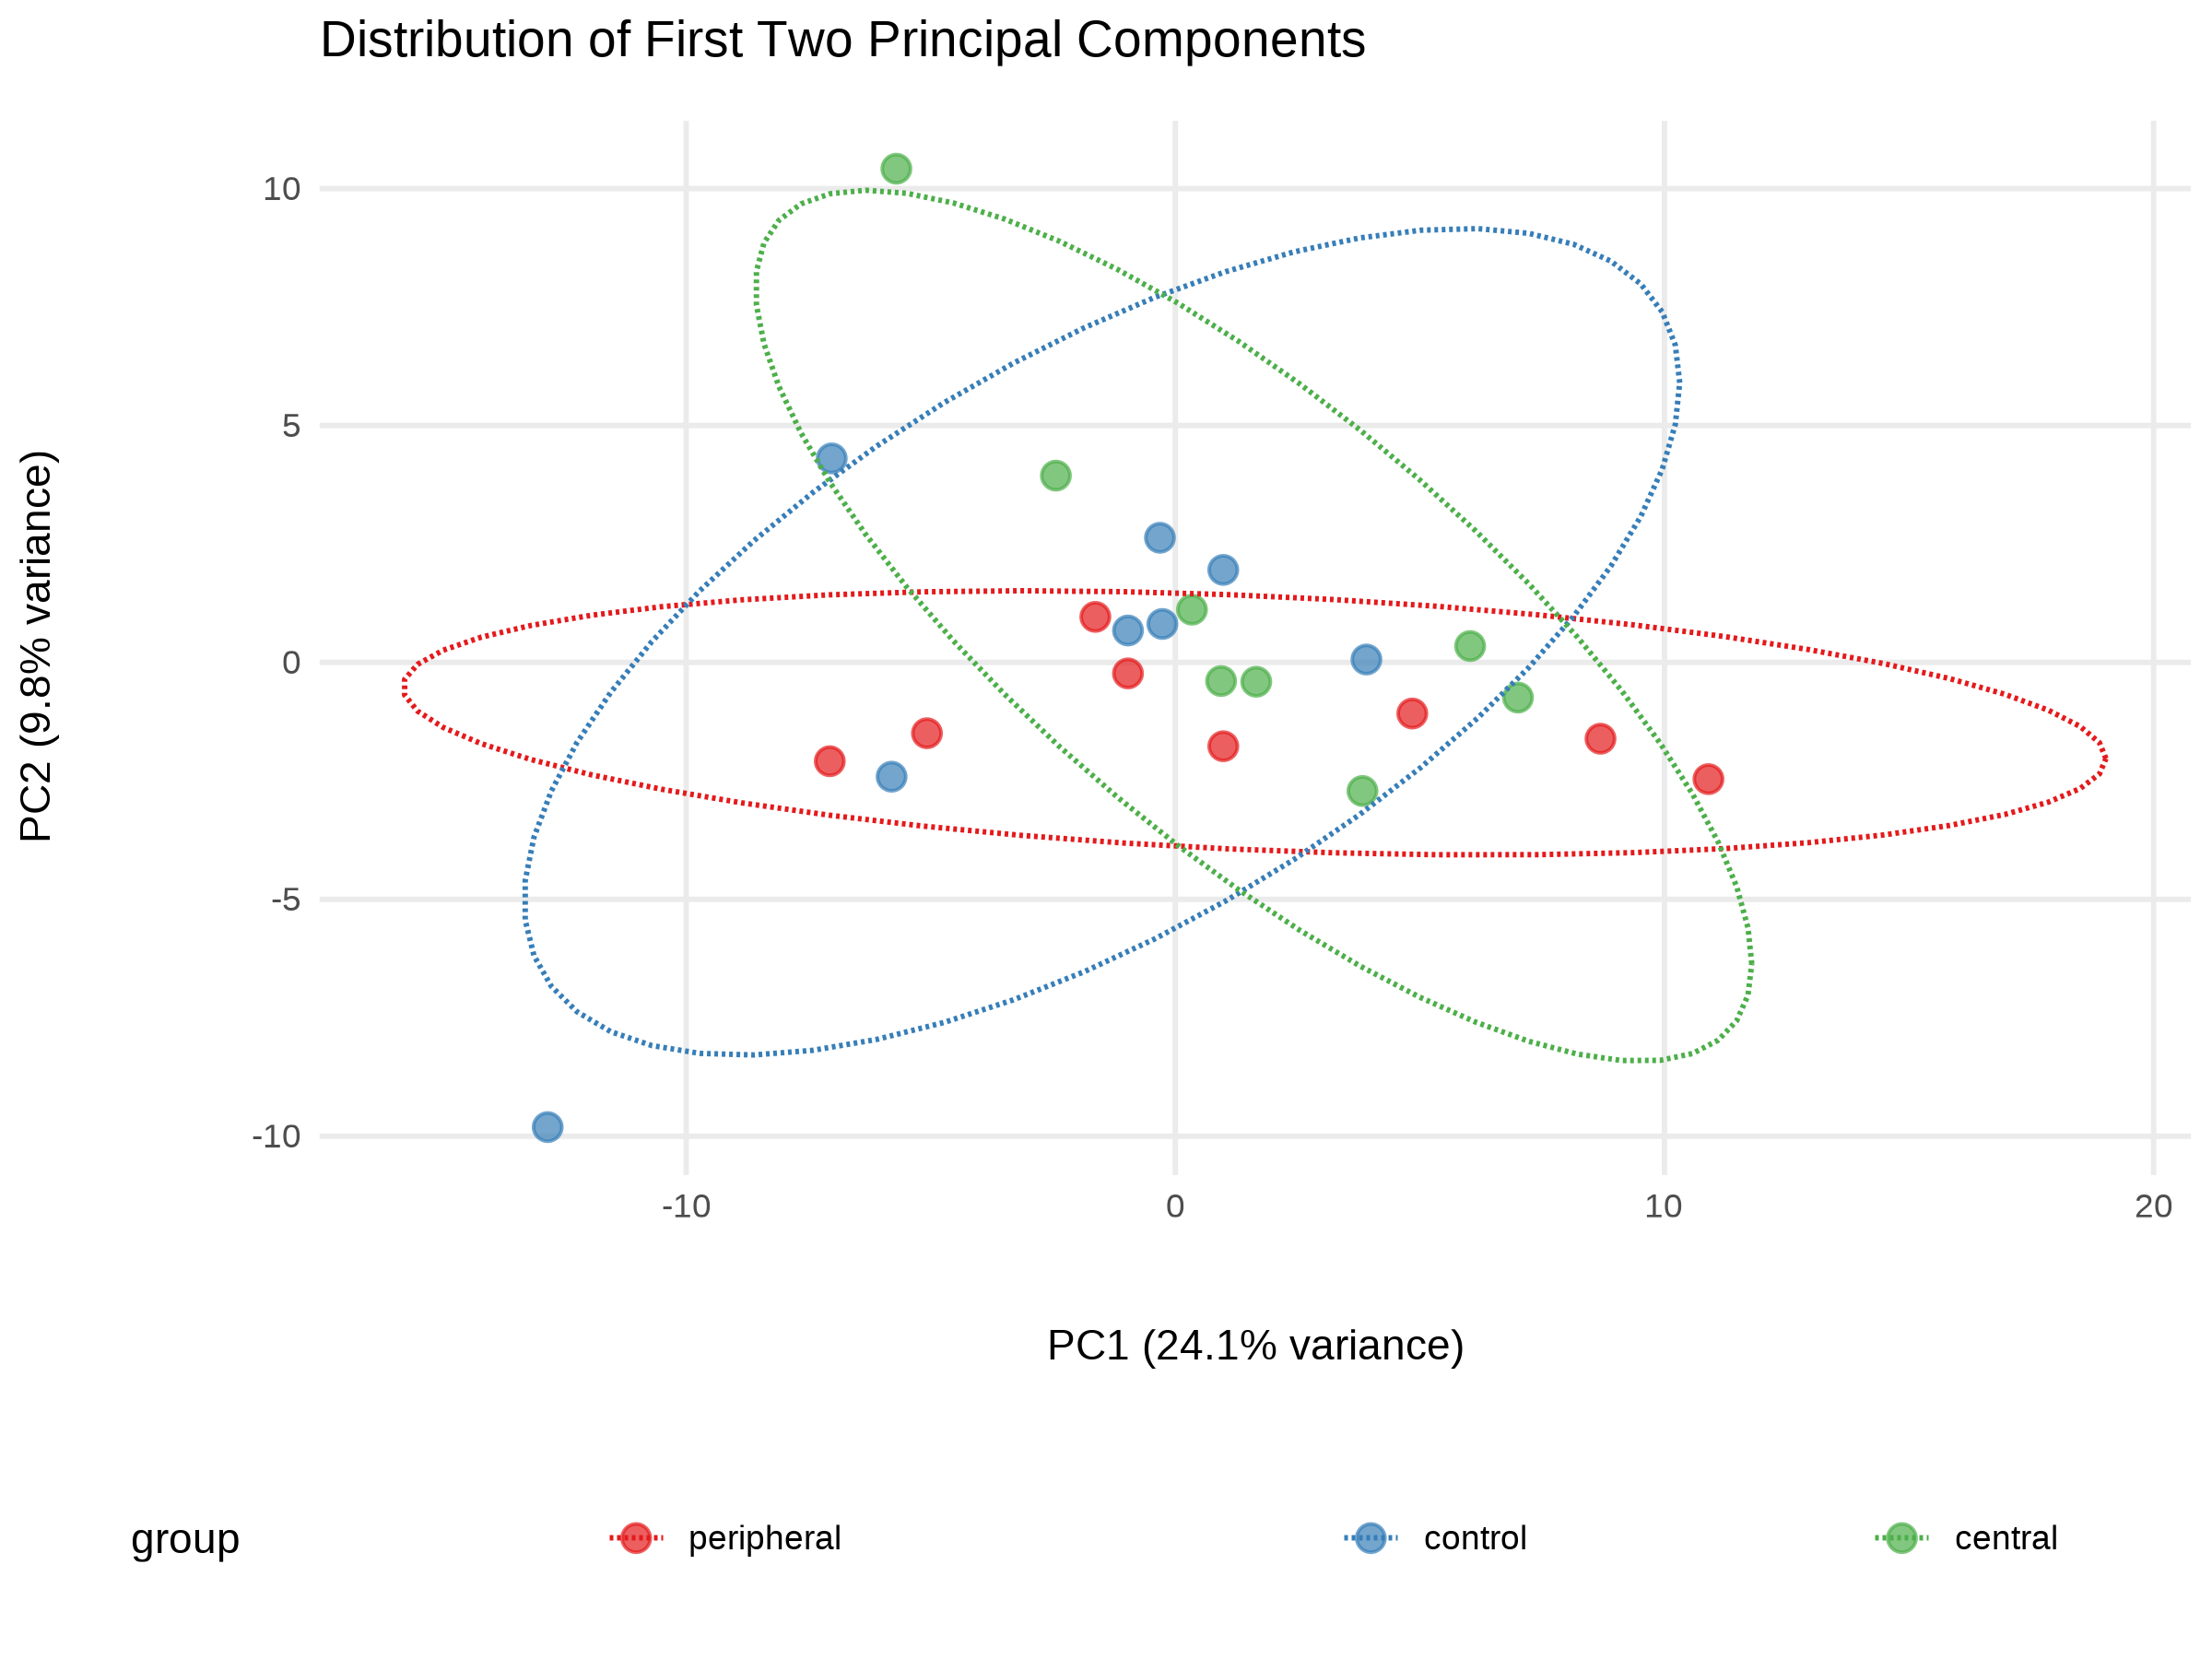

In [61]:
pca_result <- df_group_node |> 
    cut_degree_distributions(PID, connections, 0.1) |>
    perform_pca_with_knee(PID, group, building, connections)
pca_result |> plot_eigenspectrum()
pca_result |> plot_first_two_pcs()
cluster_result <- pca_result |> cluster_data(k = 3)
fig_cluster <- cluster_result |> plot_clusters()
cluster_analysis <- cluster_result |> analyze_cluster_groups()

Too few points to calculate an ellipse
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_path()`).”
Warning message in grid.Call.graphics(C_points, x$x, x$y, x$pch, x$size):
“semi-transparency is not supported on this device: reported only once per page”


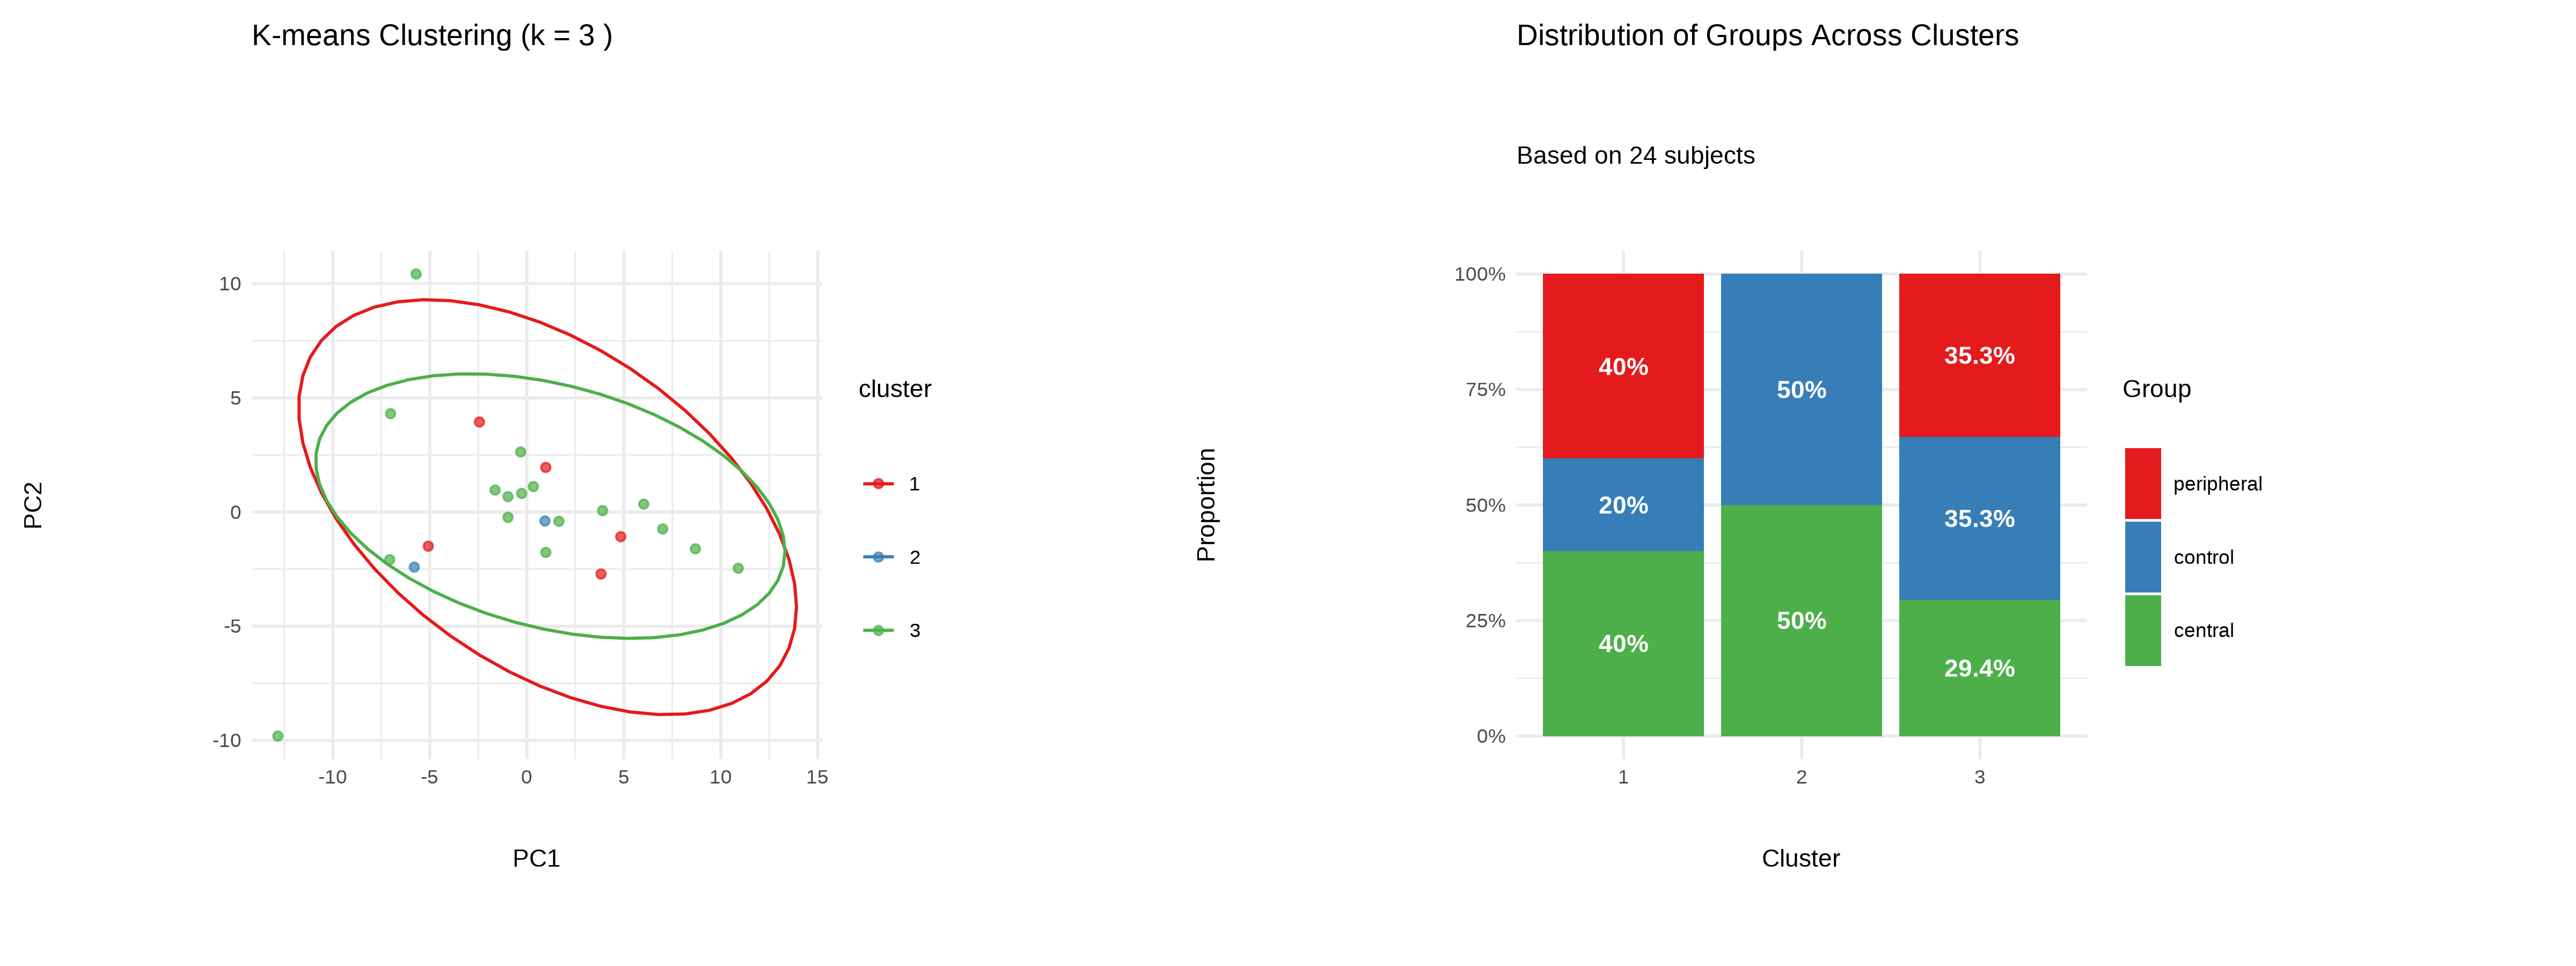

In [62]:
library(patchwork)
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_cluster | cluster_analysis$plot
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)